In [65]:
# Получение данных из базы данных и очистка
import pandas as pd
import sqlite3
conn = sqlite3.connect(r"""E:\projects\Benefit Harm\apps\PC\data\students.db""")
df_snapshots = pd.read_sql_query("select * from game_snapshots_v1", conn)
df_sessions = pd.read_sql_query("select * from sessions", conn)
df_students = pd.read_sql_query("select * from students", conn)
df_snapshots.drop(['id', 'time', 'health'], axis=1, inplace=True)
# Возраст, пол
df_snapshots = df_snapshots.merge(
    df_sessions[['id', 'student_id']], left_on="session_id", right_on="id", how="left"
)
df_snapshots = df_snapshots.merge(
    df_students[['id', 'age', 'is_male']], left_on="student_id", right_on="id", how="left")
df_snapshots.drop(['id_y', 'id_x', 'student_id'], axis=1, inplace=True)
print(df_snapshots.head())

   session_id  emotion  frequency_key_down  game_different  enemy_distance  \
0          14  neutral                   2               0             NaN   
1          14      sad                   2              15             NaN   
2          14     fear                   2              15             NaN   
3          15      sad                   2               0      714.345155   
4          15      sad                   3              15      105.948101   

  status  count_defeat  age  is_male  
0   None           NaN   18        1  
1   None           NaN   18        1  
2   None           NaN   18        1  
3   None           NaN   18        1  
4   None           NaN   18        1  


In [66]:
# Пустые значения
df_snapshots = df_snapshots.dropna(subset=["status"]).fillna(0)
print(df_snapshots.isnull().sum())

session_id            0
emotion               0
frequency_key_down    0
game_different        0
enemy_distance        0
status                0
count_defeat          0
age                   0
is_male               0
dtype: int64


In [67]:
# Разделение на y, x
y = df_snapshots[["age"]]
X = df_snapshots[["frequency_key_down", "status", "count_defeat"]]

In [68]:
# Баланс классов
print(y.value_counts())

age
46     425
18     397
Name: count, dtype: int64


In [69]:
# Строки
from sklearn.preprocessing import LabelEncoder, StandardScaler

le = LabelEncoder()
X['status'] = le.fit_transform(X['status'])
#X['time'] = pd.to_datetime(X['time'])
#X['time'] = X['time'].dt.hour

C:\Users\Work\AppData\Local\Temp\ipykernel_20852\1133817744.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X['status'] = le.fit_transform(X['status'])


In [70]:
# Разделение на тестовую и обучающую выборку
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Обучающая выборка: {X_train.shape}")
print(f"Тестовая выборка: {X_test.shape}")

Обучающая выборка: (657, 3)
Тестовая выборка: (165, 3)


In [71]:
# Обучение модели
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(class_weight="balanced")
model.fit(X_train, y_train)

E:\projects\Benefit Harm\.venv10\lib\site-packages\sklearn\utils\validation.py:1406: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [72]:
# Оценка модели
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

y_pred = model.predict(X_test)

print(f"Точность (Accuracy): {accuracy_score(y_test, y_pred):.3f}")
print(f"Матрица предсказаний: \n{confusion_matrix(y_test, y_pred)}")

Точность (Accuracy): 0.824
Матрица предсказаний: 
[[75  1]
 [28 61]]


count_defeat          3.838523
frequency_key_down   -0.059923
status               -1.490906
dtype: float64


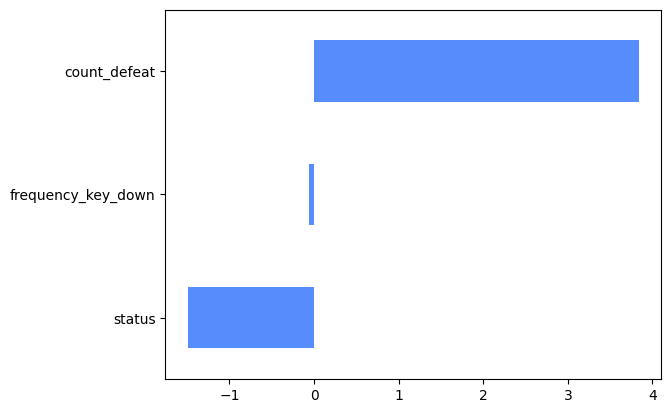

In [73]:
# Для LogisticRegression / LinearRegression
import matplotlib.pyplot as plt
coef = pd.Series(model.coef_[0], index=X.columns)
print(coef.sort_values(ascending=False))

# Визуализация
coef.sort_values().plot(kind='barh')
plt.show()